# Reviews Exploration Notebook

## Overview

This notebook is my main exploratory workspace for the course review dataset. The goal here isn't to produce final outputs — it's to understand the data: where it comes from, how it's distributed, what patterns emerge across time, courses, formats, and reviewer roles, and what the text itself is actually saying.

Everything downstream (the sentiment analysis, the statistical analysis, the dashboard export) depends on having a solid understanding of the raw shape of this data, and that's what this notebook is for.

## Goals

- Get a clear picture of how reviews are distributed across ratings, platforms, courses, and formats
- Identify any obvious data quality issues or surprises before they cause problems in later pipelines
- Understand trends over time — both in volume and in sentiment
- Surface the language students actually use when they're happy or unhappy
- Produce a summary CSV that can be referenced quickly without re-running the full analysis

## Data Source

The data is loaded directly from the cleaning pipeline (`src_reviews_cleaning.pipeline.run()`), so this notebook always reflects the most current cleaned dataset. No manual file loading required.

# Imports

In [ ]:
# !pip install vaderSentiment lingua-language-detector deep-translator wordcloud scikit-learn -q

In [ ]:

from google.colab import drive
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from importlib import reload

In [ ]:
# Connect to Google Drive
drive.mount('/content/drive', force_remount=True)

# Add the src package to the Python path
BASE_DIR = '/content/drive/Shareddrives/essentis_intern_drive'
DATA_DIR = os.path.join(BASE_DIR, 'data')
if DATA_DIR not in sys.path:
    sys.path.insert(0, DATA_DIR)

# Define output directory for charts and summary CSV
OUTPUT_DIR       = os.path.join(BASE_DIR, 'charts', 'exploration')
CHARTS_DIR       = os.path.join(OUTPUT_DIR, 'charts')
SUMMARY_CSV_PATH = os.path.join(OUTPUT_DIR, 'summary.csv')

# Create output folders if they do not exist yet
os.makedirs(CHARTS_DIR, exist_ok=True)

# Apply seaborn default theme to all charts
sns.set_theme()

print("Setup complete.")
print("Charts will save to:", CHARTS_DIR)
print("Summary CSV will save to:", SUMMARY_CSV_PATH)

Mounted at /content/drive
Setup complete.
Charts will save to: /content/drive/Shareddrives/essentis_intern_drive/charts/exploration/charts
Summary CSV will save to: /content/drive/Shareddrives/essentis_intern_drive/charts/exploration/summary.csv


In [ ]:
sys.path.insert(0, '/content/drive/Shareddrive')

In [ ]:
# Load the cleaned DataFrame directly from the pipeline.
# This ensures the exploration always uses the most up to date cleaned data.

from src_reviews_cleaning.pipeline import run

df = run()

print("Shape:", df.shape)
print("Date range:", df['review_date'].min(), "to", df['review_date'].max())
print("\nSource breakdown:")
print(df['data_source'].value_counts())

Step 1/4: Loading raw data...
  google: 256 rows
  clean: 541 rows
  new: 49 rows
Step 2/4: Normalizing columns...
  Combined shape: (846, 17)
Step 3/4: Cleaning data (includes language detection + translation)...


/content/drive/Shareddrives/essentis_intern_drive/data/src_reviews_cleaning/normalizers.py:292: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(normalized, ignore_index=True)


  [17/846] Translated from FRENCH: Très bonne école de formation. Les cours sont bien...
  [206/846] Translated from GERMAN: Der KI Kompaktkurs bei WBS Coding School bietet ei...
  [207/846] Translated from GERMAN: Abhängig vom eigenen Skillset und der jeweiligen G...
  [208/846] Translated from GERMAN: Der AI Compact-Kurs war ausgezeichnet. Er hat mir ...
  [209/846] Translated from GERMAN: Von Mai bis Juli 2025 habe ich an der WBS eine Wei...
  [210/846] Translated from GERMAN: Das Bootcamp "AI for Business" war für mich ein ec...
  [211/846] Translated from GERMAN: Ich habe den Data Science-Kurs abgeschlossen und e...
  [212/846] Translated from GERMAN: Anfangs war ich unsicher, ob mein Vorwissen für da...
  [213/846] Translated from GERMAN: Ich bin mit wenig Programmier-Erfahrung ins Data S...
  [214/846] Translated from GERMAN: Ich habe in den letzten 8 Wochen am KI-Kurs der WB...
  [215/846] Translated from GERMAN: Ich kann die WBS Coding School jedem empfehlen, de...
  [216/846]

In [ ]:
# Use translated text for non-English reviews, original for English.
# This ensures text analysis cells run on English text only.
df['text_for_analysis'] = df['review_text_translated'].where(
    df['review_text_translated'].notna(), df['review_text']
)

## Rating Distributions


The first thing I want to understand is the overall shape of the ratings. I'm looking at two things here: the `overall_experience` score (a single averaged value per review) and the four individual rating dimensions — `review`, `instructors`, `curriculum`, and `job_assistance`. Seeing these side by side tells me whether students tend to rate all dimensions similarly or whether certain areas pull the average up or down. A heavy skew toward 4s and 5s is typical for bootcamp reviews, so I'm paying attention to whether any dimension breaks that pattern.

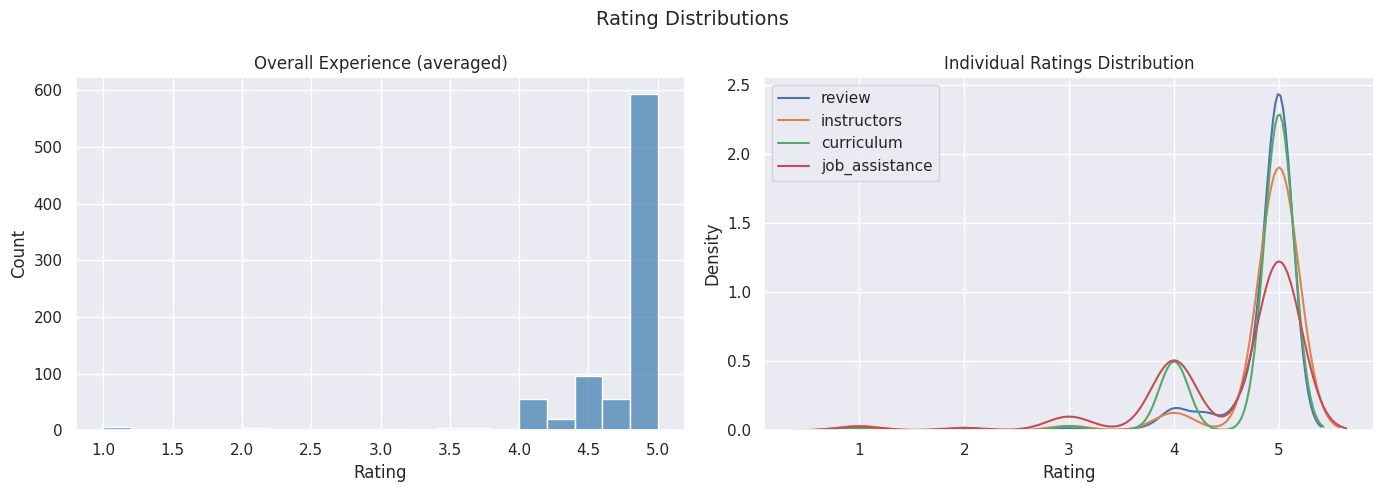

Saved: rating_distributions.png


In [ ]:
# Two charts:
# 1. overall_experience distribution (single rating)
# 2. all four individual ratings side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Rating Distributions", fontsize=14)

RATING_COLUMNS = ['review', 'instructors', 'curriculum', 'job_assistance']

# --- Chart 1: overall_experience distribution ---
sns.histplot(
    data=df,
    x='overall_experience',
    bins=20,
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title("Overall Experience (averaged)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

# --- Chart 2: all four individual ratings overlaid ---
for col in RATING_COLUMNS:
    sns.kdeplot(
        data=df[col].dropna(),
        ax=axes[1],
        label=col,
        fill=False
    )
axes[1].set_title("Individual Ratings Distribution")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'rating_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rating_distributions.png")

## Review Volume Over Time

Before reading too much into rating trends, I need to understand when reviews were actually being written. This section looks at review volume month by month, and breaks that volume down by platform. Spikes in volume can skew rating averages — if 200 reviews landed in one month from a single platform, that matters. This chart helps me spot those moments and interpret the rest of the analysis with the right context.

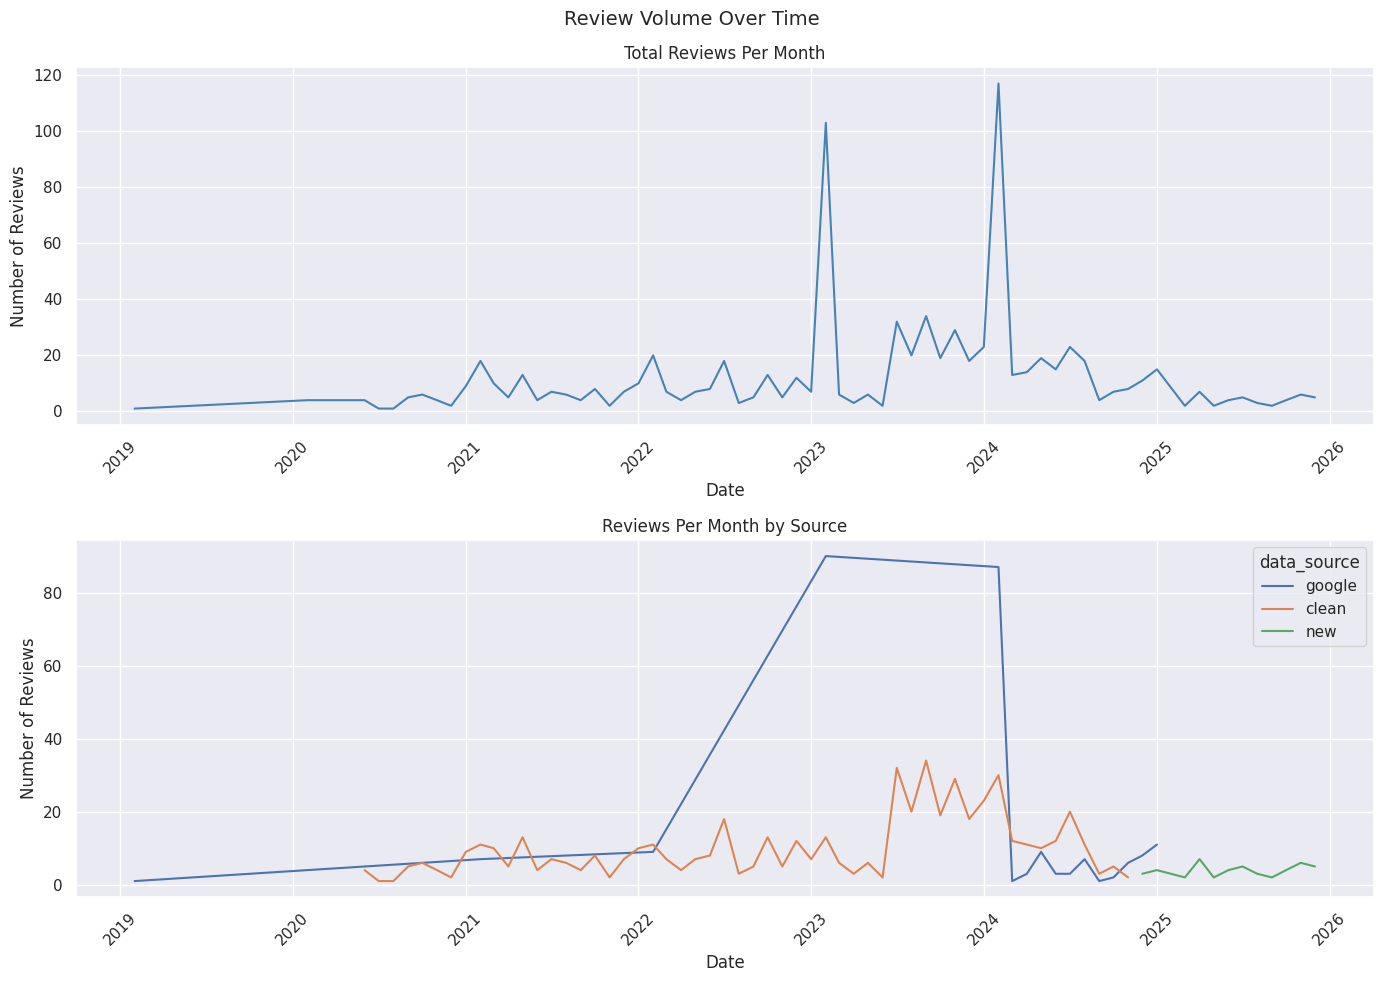

Saved: review_volume_over_time.png


In [ ]:
# Shows how many reviews were posted per month across all sources.
# A second chart breaks this down by data_source so we can see
# which platform was most active at any given time.

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Review Volume Over Time", fontsize=14)

# Add a year-month column for grouping
df['year_month'] = df['review_date'].dt.to_period('M')

# --- Chart 1: total reviews per month ---
volume = df.groupby('year_month').size().reset_index(name='count')
# Convert period to timestamp for plotting
volume['year_month'] = volume['year_month'].dt.to_timestamp()
sns.lineplot(data=volume, x='year_month', y='count', ax=axes[0], color='steelblue')
axes[0].set_title("Total Reviews Per Month")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Number of Reviews")
axes[0].tick_params(axis='x', rotation=45)

# --- Chart 2: reviews per month broken down by data_source ---
volume_by_source = df.groupby(['year_month', 'data_source']).size().reset_index(name='count')
volume_by_source['year_month'] = volume_by_source['year_month'].dt.to_timestamp()
sns.lineplot(
    data=volume_by_source,
    x='year_month',
    y='count',
    hue='data_source',
    ax=axes[1]
)
axes[1].set_title("Reviews Per Month by Source")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Number of Reviews")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'review_volume_over_time.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: review_volume_over_time.png")

## Review Sources

The dataset is aggregated from multiple platforms (Course Report, SwitchUp, Google, and others). This section answers two questions: where are most of our reviews coming from, and do ratings differ meaningfully by platform? Platform-level rating differences can reflect genuine quality signals, but they can also reflect differences in the reviewer populations or review cultures on each site. Worth keeping in mind when making cross-platform comparisons.

/tmp/ipykernel_227/39065788.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(data=source_counts, x='count', y='source', hue='source', legend=False, ax=axes[0], color='steelblue')
/tmp/ipykernel_227/39065788.py:20: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(data=source_ratings, x='avg_rating', y='source', hue='source', legend=False, ax=axes[1], color='steelblue')


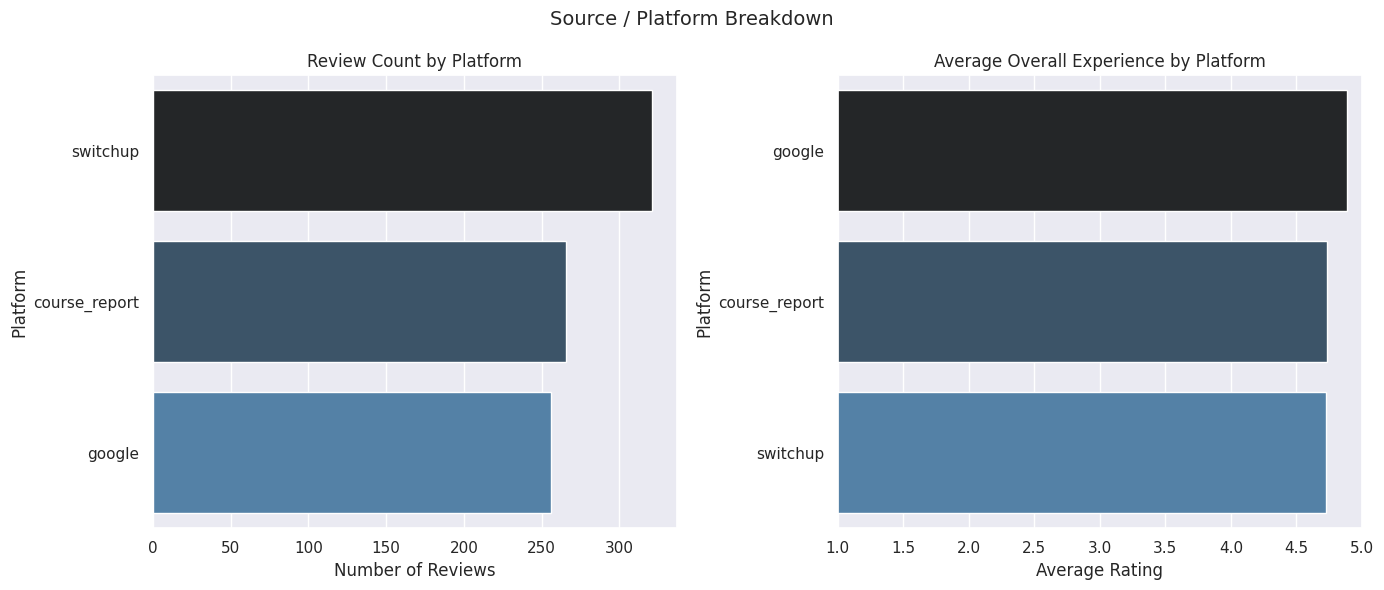

Saved: source_breakdown.png


In [ ]:
# Shows the distribution of reviews across platforms (course_report, switchup, google, etc.)
# A second chart shows the average overall_experience rating per platform
# so we can see if ratings differ across sources.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Source / Platform Breakdown", fontsize=14)

# --- Chart 1: review count per platform ---
source_counts = df['source'].value_counts().reset_index()
source_counts.columns = ['source', 'count']
sns.barplot(data=source_counts, x='count', y='source', hue='source', legend=False, ax=axes[0], color='steelblue')
axes[0].set_title("Review Count by Platform")
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("Platform")

# --- Chart 2: average overall_experience per platform ---
source_ratings = df.groupby('source')['overall_experience'].mean().reset_index()
source_ratings.columns = ['source', 'avg_rating']
source_ratings = source_ratings.sort_values('avg_rating', ascending=False)
sns.barplot(data=source_ratings, x='avg_rating', y='source', hue='source', legend=False, ax=axes[1], color='steelblue')
axes[1].set_title("Average Overall Experience by Platform")
axes[1].set_xlabel("Average Rating")
axes[1].set_ylabel("Platform")
axes[1].set_xlim(1, 5)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'source_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: source_breakdown.png")

## Course Format

Students can attend full-time or part-time. This section looks at how the two groups differ in size and in how they rate their experience. It's a straightforward split, but an important one — full-time and part-time students have very different experiences of the same curriculum, and any recommendation or report that ignores that distinction risks being misleading.





/tmp/ipykernel_227/372055845.py:14: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(data=format_counts, x='course_format', y='count', hue='course_format', legend=False, ax=axes[0], color='steelblue')
/tmp/ipykernel_227/372055845.py:22: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(data=format_ratings, x='course_format', y='avg_rating', hue='course_format', legend=False, ax=axes[1], color='steelblue')


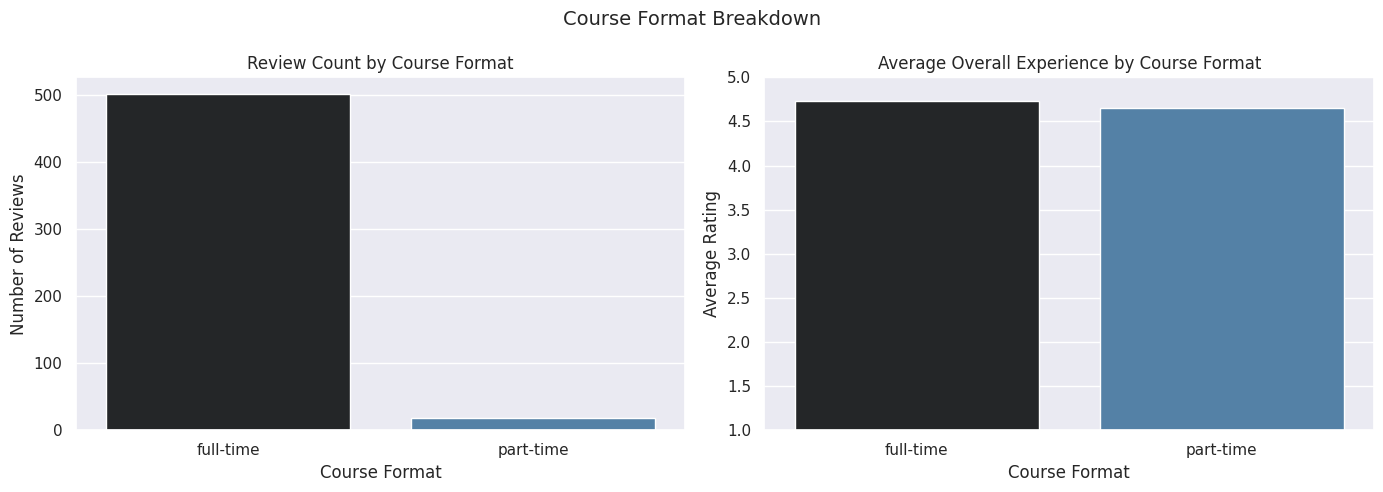

Saved: course_format_breakdown.png


In [ ]:
# Shows the split between full-time and part-time students.
# A second chart shows the average overall_experience rating per format
# so we can see if full-time vs part-time students rate differently.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Course Format Breakdown", fontsize=14)

# Drop NaN course_format rows for both charts
format_df = df.dropna(subset=['course_format'])

# --- Chart 1: review count per course format ---
format_counts = format_df['course_format'].value_counts().reset_index()
format_counts.columns = ['course_format', 'count']
sns.barplot(data=format_counts, x='course_format', y='count', hue='course_format', legend=False, ax=axes[0], color='steelblue')
axes[0].set_title("Review Count by Course Format")
axes[0].set_xlabel("Course Format")
axes[0].set_ylabel("Number of Reviews")

# --- Chart 2: average overall_experience per course format ---
format_ratings = format_df.groupby('course_format')['overall_experience'].mean().reset_index()
format_ratings.columns = ['course_format', 'avg_rating']
sns.barplot(data=format_ratings, x='course_format', y='avg_rating', hue='course_format', legend=False, ax=axes[1], color='steelblue')
axes[1].set_title("Average Overall Experience by Course Format")
axes[1].set_xlabel("Course Format")
axes[1].set_ylabel("Average Rating")
# Set y axis to start at 1 to better show differences between formats
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'course_format_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: course_format_breakdown.png")

## Text Analysis

Numbers only tell part of the story. This section looks at the review text itself — specifically, how long reviews tend to be and what words come up most often. I'm using a custom stopword list to filter out generic filler words and school-specific terms (like the school name itself) so the wordcloud reflects actual student sentiment rather than noise. Review length distribution is useful as a proxy for engagement: very short reviews often have less signal, and very long ones sometimes indicate strong emotion in either direction.

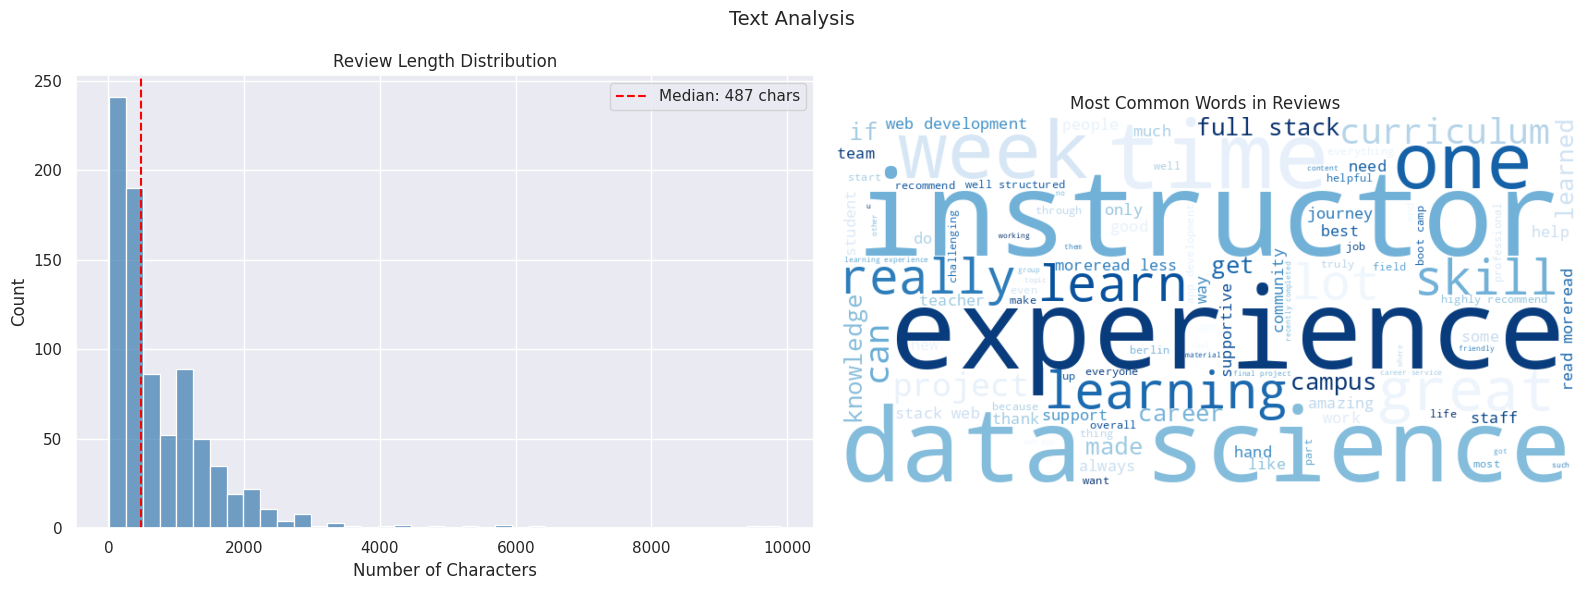

Saved: text_analysis.png
Median review length: 487 characters
Reviews analyzed: 822


In [ ]:
# Two charts:
# 1. Distribution of review text length (in characters)
# 2. Wordcloud of the most common words across all review text

# Common words that carry no meaning and should be excluded from the wordcloud
STOPWORDS = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "is", "was", "it", "i", "my", "me", "we", "our", "you",
    "your", "they", "their", "this", "that", "have", "had", "has", "be",
    "been", "are", "were", "not", "so", "as", "from", "by", "all", "very",
    "also", "more", "about", "which", "would", "could", "will", "what",
    "who", "how", "when", "there", "than", "just", "after", "during",
    "school", "wbs", "coding", "bootcamp", "course", "program"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Text Analysis", fontsize=14)

# Drop rows with no review text
text_df = df.dropna(subset=['review_text'])

# --- Chart 1: review length distribution ---
# Calculate character count for each review
text_df = text_df.copy()
text_df['review_length'] = text_df['text_for_analysis'].str.len()
sns.histplot(data=text_df, x='review_length', bins=40, ax=axes[0], color='steelblue')
axes[0].set_title("Review Length Distribution")
axes[0].set_xlabel("Number of Characters")
axes[0].set_ylabel("Count")

# Add a vertical line at the median review length
median_length = text_df['review_length'].median()
axes[0].axvline(median_length, color='red', linestyle='--', label=f'Median: {int(median_length)} chars')
axes[0].legend()

# --- Chart 2: wordcloud of most common words ---
# Combine all review text into one string, lowercase
all_text = " ".join(text_df['text_for_analysis'].str.lower().tolist())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=STOPWORDS,
    max_words=100,
    colormap='Blues'
).generate(all_text)

axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Most Common Words in Reviews")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'text_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: text_analysis.png")
print(f"Median review length: {int(median_length)} characters")
print(f"Reviews analyzed: {len(text_df)}")

## Rating Over Time

Now that I understand the volume patterns, I want to see how the ratings themselves have moved year over year. I'm looking at this three ways: mean trend lines (to see direction), box plots per year (to see spread and outliers), and a combined view that overlays the mean on top of the box plots. Looking at all five rating dimensions together often reveals that `job_assistance` behaves differently from the others — it tends to be more variable and more sensitive to economic conditions. Worth flagging if that pattern shows up here.

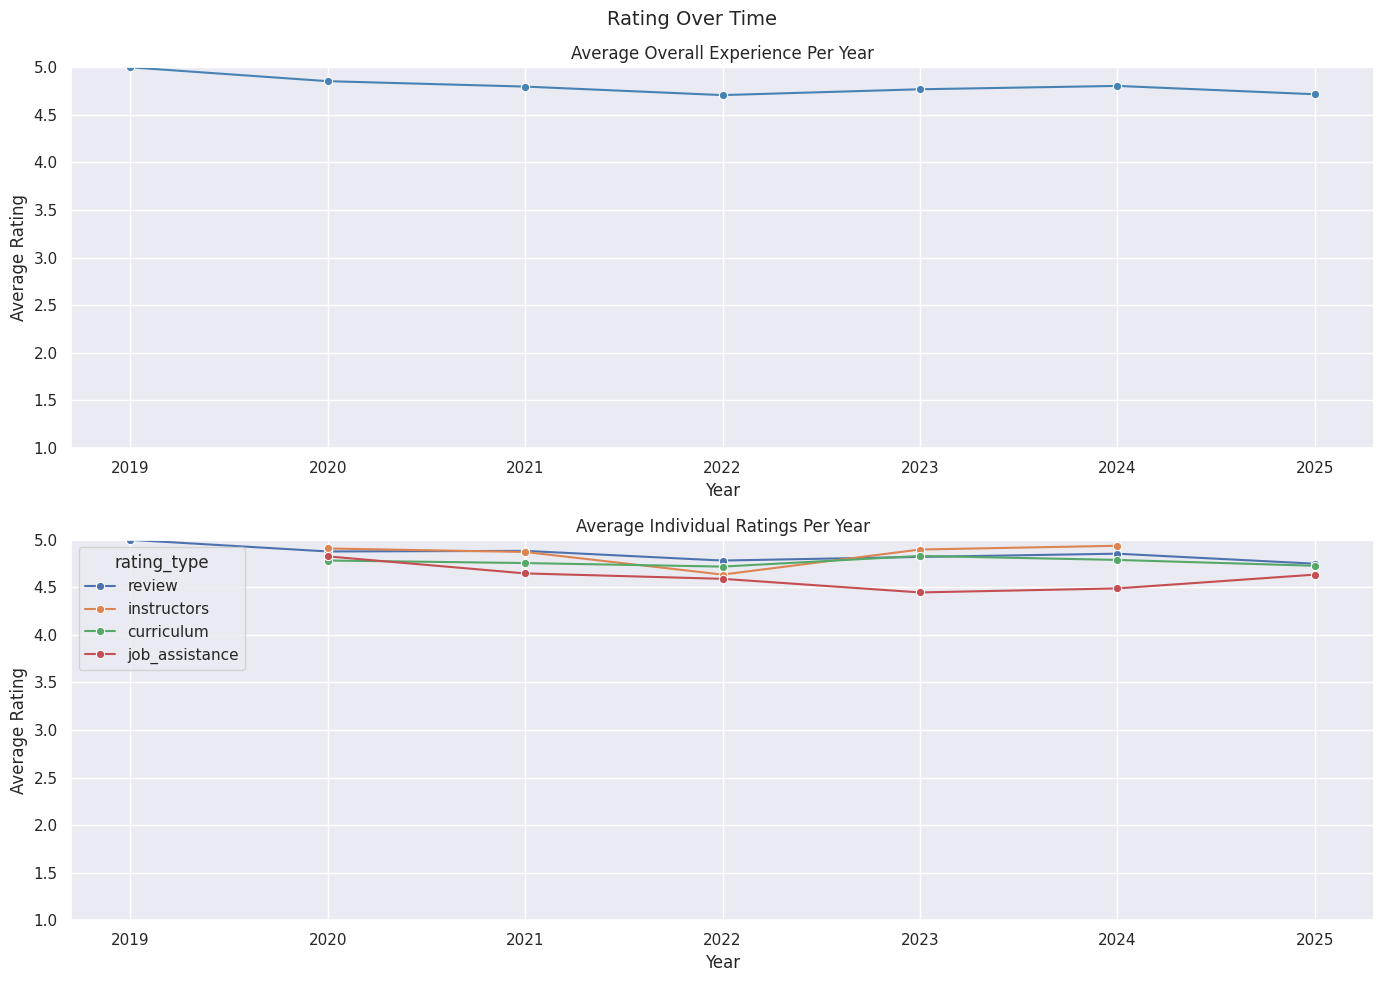

Saved: rating_over_time.png


In [ ]:
# Shows how overall_experience has trended year over year.
# A second chart breaks this down by individual rating column
# so we can see if any specific area has improved or declined.

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Rating Over Time", fontsize=14)

# Group by year for a cleaner trend line
df['year'] = df['review_date'].dt.year

# --- Chart 1: average overall_experience per year ---
rating_by_year = df.groupby('year')['overall_experience'].mean().reset_index()
sns.lineplot(data=rating_by_year, x='year', y='overall_experience', ax=axes[0], color='steelblue', marker='o')
axes[0].set_title("Average Overall Experience Per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Rating")
axes[0].set_ylim(1, 5)

# --- Chart 2: average of each individual rating per year ---
RATING_COLUMNS = ['review', 'instructors', 'curriculum', 'job_assistance']
rating_cols_by_year = df.groupby('year')[RATING_COLUMNS].mean().reset_index()
# Melt to long format so seaborn can plot each rating as a separate line
rating_cols_melted = rating_cols_by_year.melt(id_vars='year', var_name='rating_type', value_name='avg_rating')
sns.lineplot(data=rating_cols_melted, x='year', y='avg_rating', hue='rating_type', ax=axes[1], marker='o')
axes[1].set_title("Average Individual Ratings Per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average Rating")
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'rating_over_time.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rating_over_time.png")

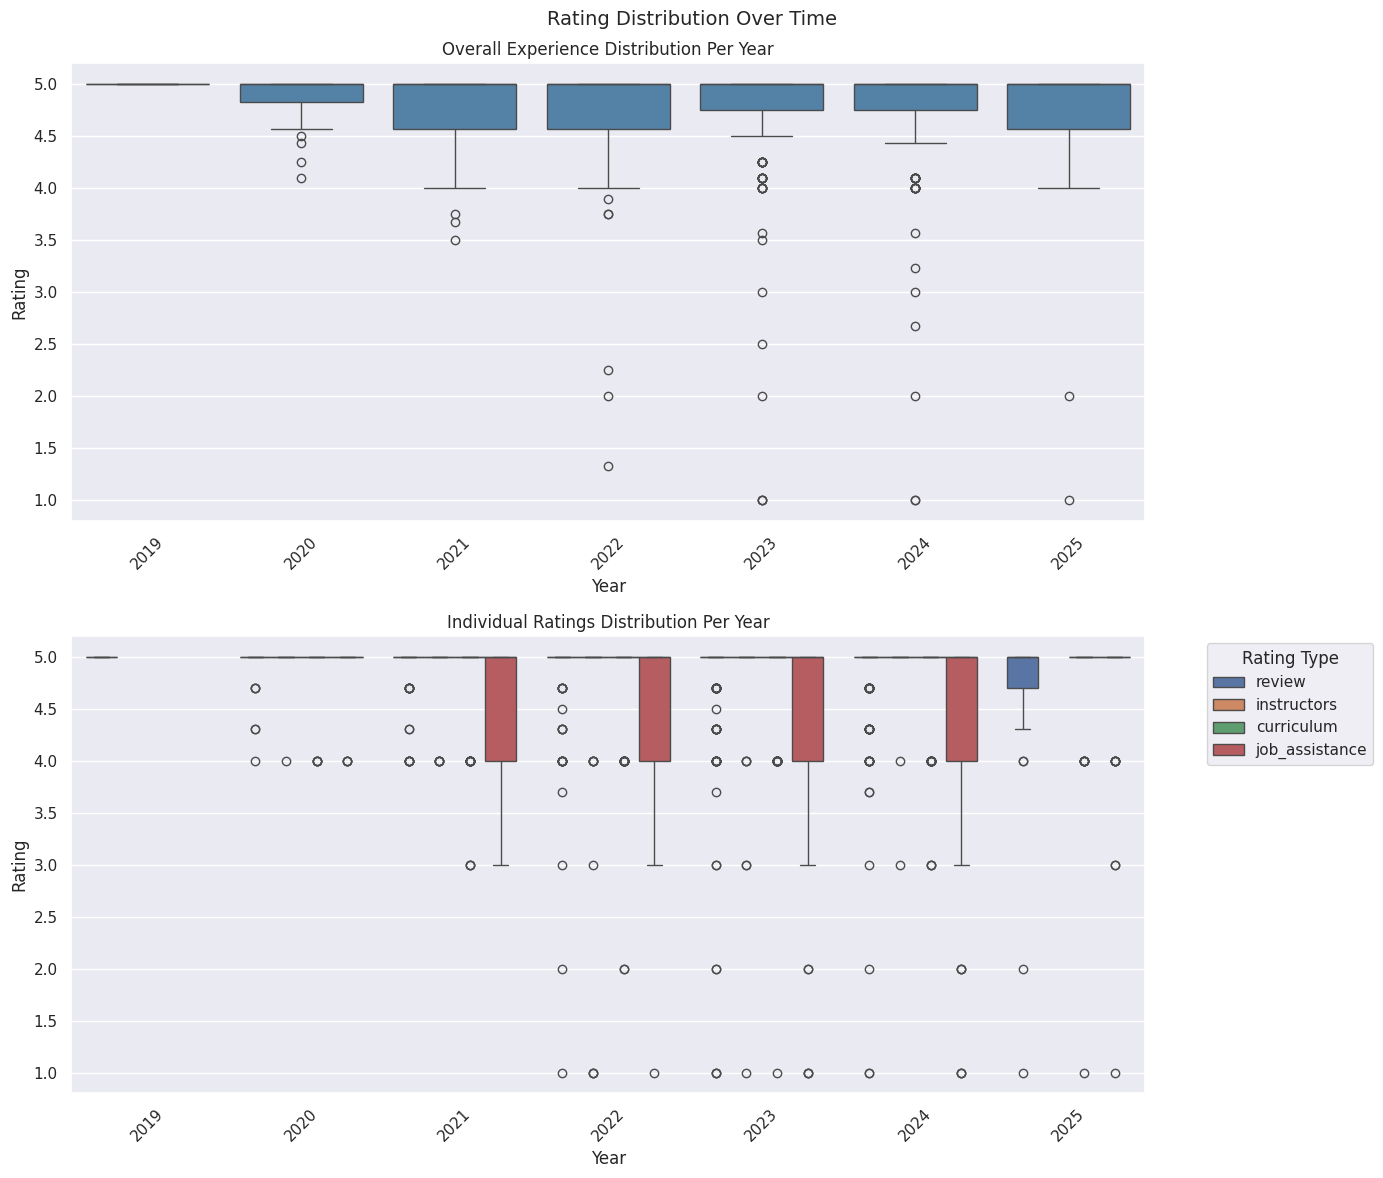

Saved: rating_over_time_boxplot.png


In [ ]:
# Rating Over Time - Box Plots
# Shows the spread of ratings per year including outliers.
# Null dates are dropped. Years are sorted chronologically.

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle("Rating Distribution Over Time", fontsize=14)

# Drop null dates and sort years chronologically
box_df = df.dropna(subset=['review_date']).copy()
box_df['year'] = box_df['review_date'].dt.year.astype(int).astype(str)
year_order = sorted(box_df['year'].unique())

# --- Chart 1: overall_experience spread per year ---
sns.boxplot(data=box_df, x='year', y='overall_experience', order=year_order, ax=axes[0], color='steelblue')
axes[0].set_title("Overall Experience Distribution Per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Rating")
axes[0].tick_params(axis='x', rotation=45)

# --- Chart 2: individual ratings spread per year ---
RATING_COLUMNS = ['review', 'instructors', 'curriculum', 'job_assistance']
melted = box_df.melt(
    id_vars='year',
    value_vars=RATING_COLUMNS,
    var_name='rating_type',
    value_name='rating'
)
sns.boxplot(data=melted, x='year', y='rating', hue='rating_type', order=year_order, ax=axes[1])
axes[1].set_title("Individual Ratings Distribution Per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Rating")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Rating Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'rating_over_time_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rating_over_time_boxplot.png")

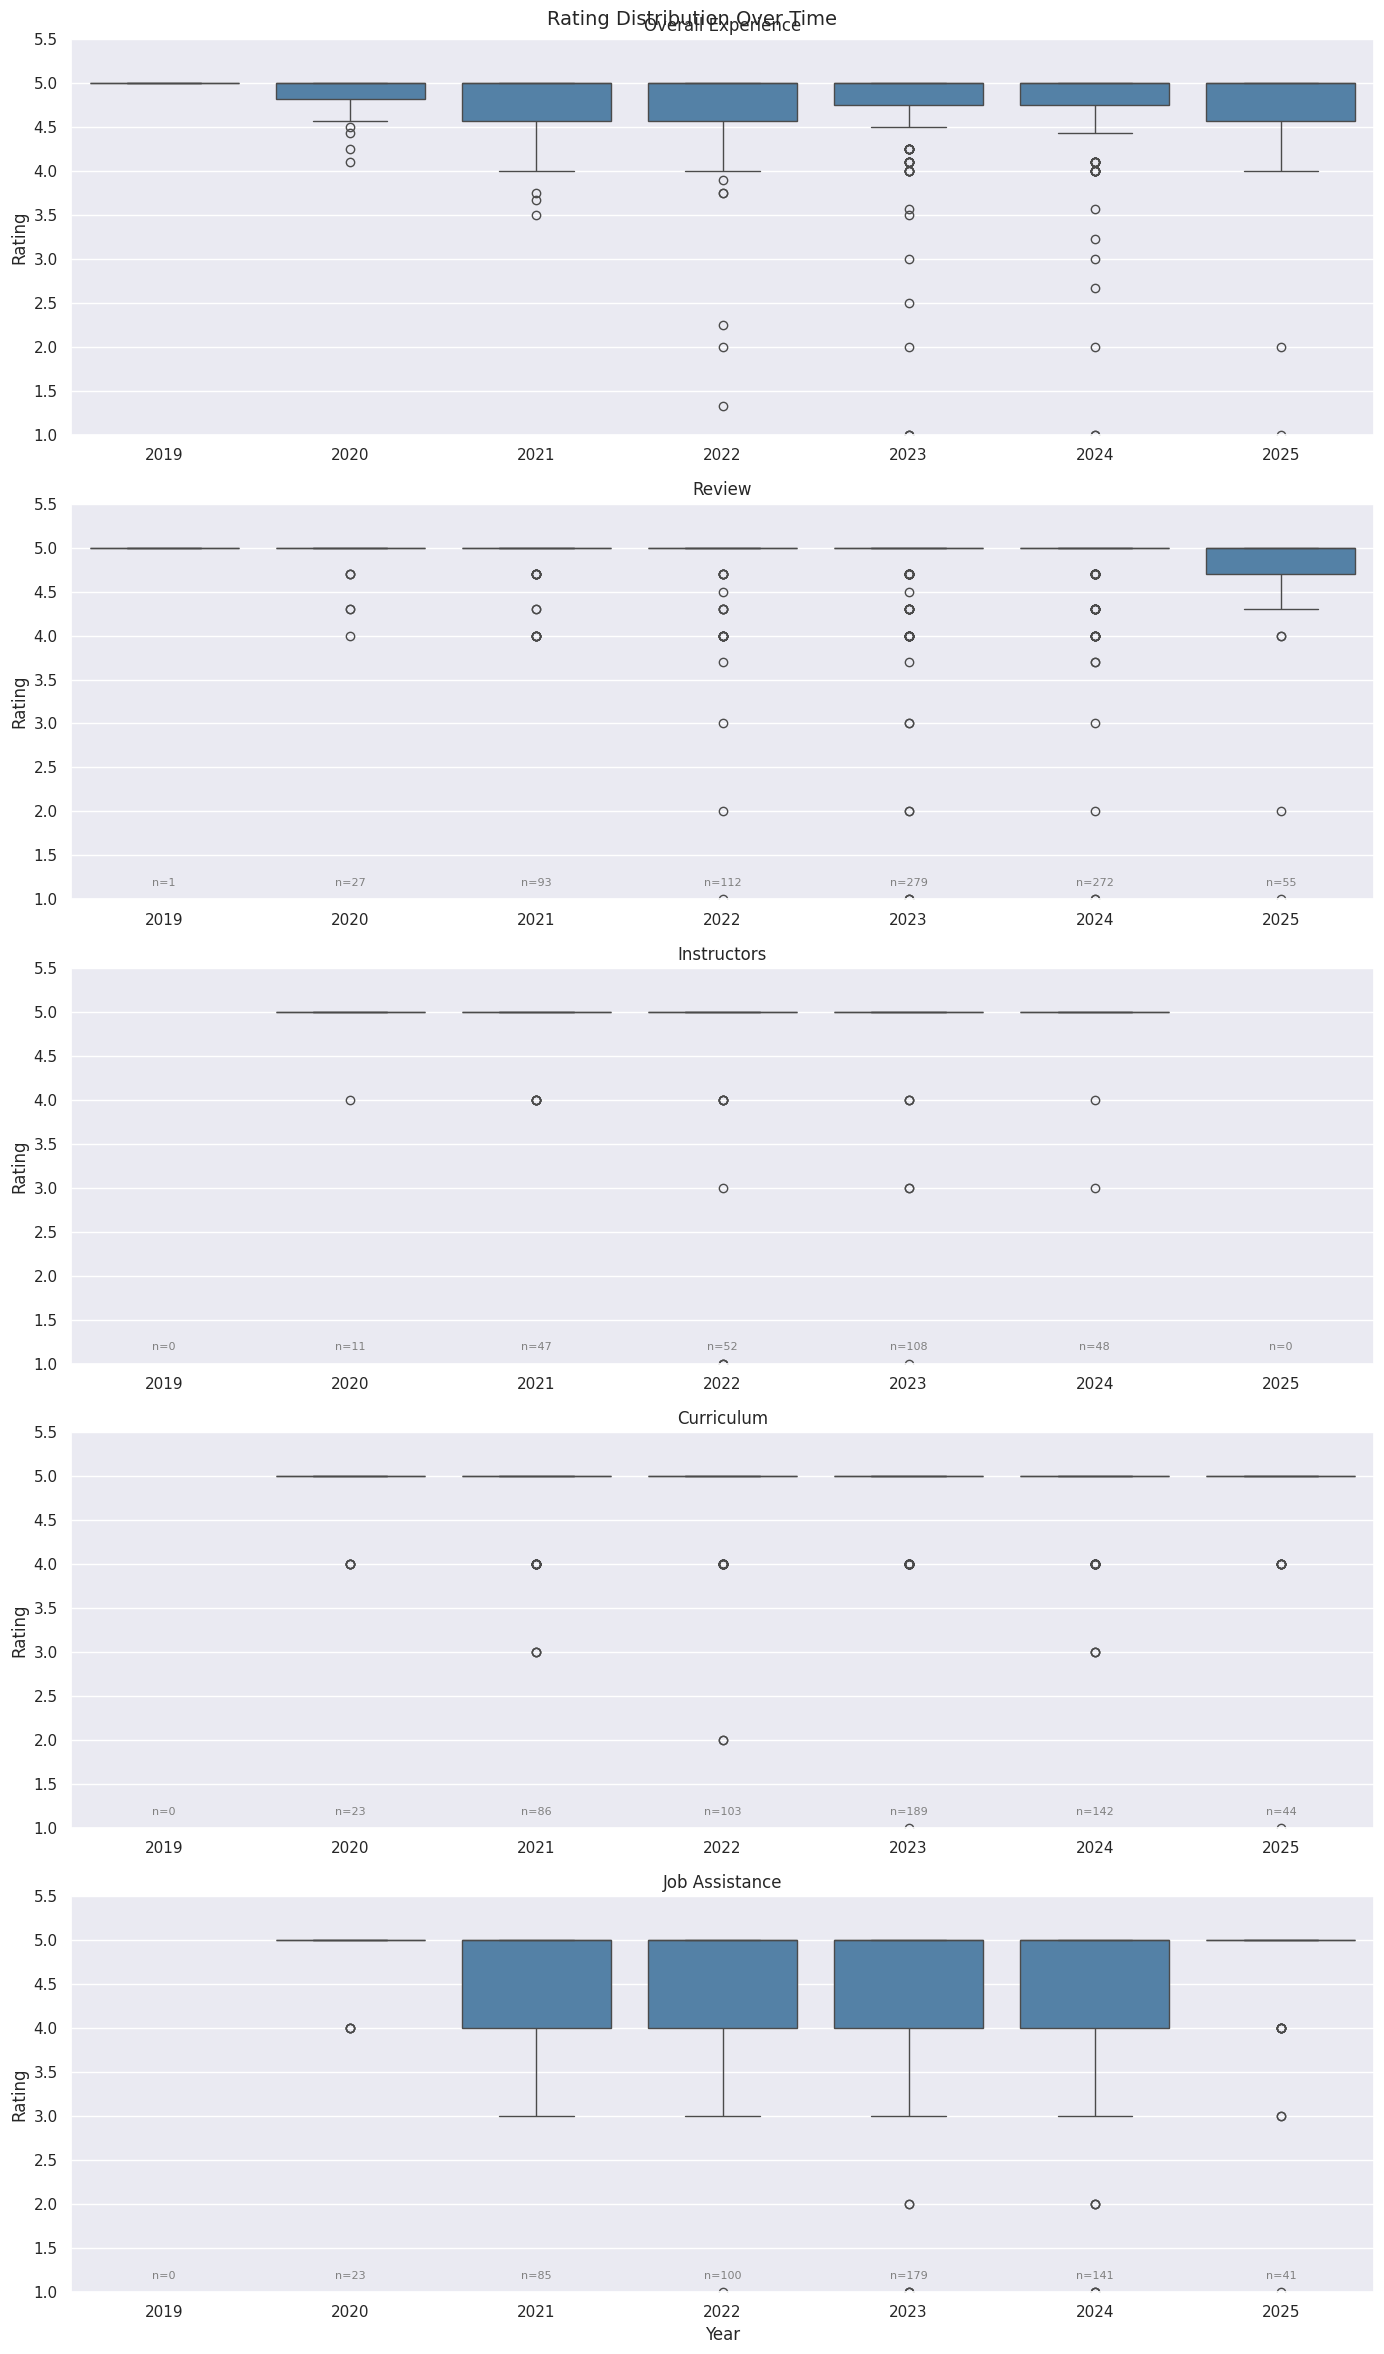

Saved: rating_over_time_boxplot.png


In [ ]:
# Rating Distribution Over Time - Box Plots
# Each rating gets its own subplot for readability.
# Null dates are dropped. Years are sorted chronologically.

# Drop null dates and sort years chronologically
box_df = df.dropna(subset=['review_date']).copy()
box_df['year'] = box_df['review_date'].dt.year.astype(int).astype(str)
year_order = sorted(box_df['year'].unique())

RATING_COLUMNS = ['review', 'instructors', 'curriculum', 'job_assistance']

# One row for overall_experience, one row per individual rating
fig, axes = plt.subplots(5, 1, figsize=(14, 24))
fig.suptitle("Rating Distribution Over Time", fontsize=14)

# --- Overall experience ---
sns.boxplot(data=box_df, x='year', y='overall_experience', order=year_order, ax=axes[0], color='steelblue')
axes[0].set_title("Overall Experience")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rating")
axes[0].set_ylim(1, 5.5)

# --- One chart per individual rating ---
for i, col in enumerate(RATING_COLUMNS):
    sns.boxplot(data=box_df.dropna(subset=[col]), x='year', y=col, order=year_order, ax=axes[i+1], color='steelblue')
    axes[i+1].set_title(col.replace('_', ' ').title())
    axes[i+1].set_xlabel("Year" if i == len(RATING_COLUMNS) - 1 else "")
    axes[i+1].set_ylabel("Rating")
    axes[i+1].set_ylim(1, 5.5)
    # Add sample size per year as annotation
    for j, year in enumerate(year_order):
        n = box_df[box_df['year'] == year][col].dropna().shape[0]
        axes[i+1].text(j, 1.15, f'n={n}', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'rating_over_time_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rating_over_time_boxplot.png")

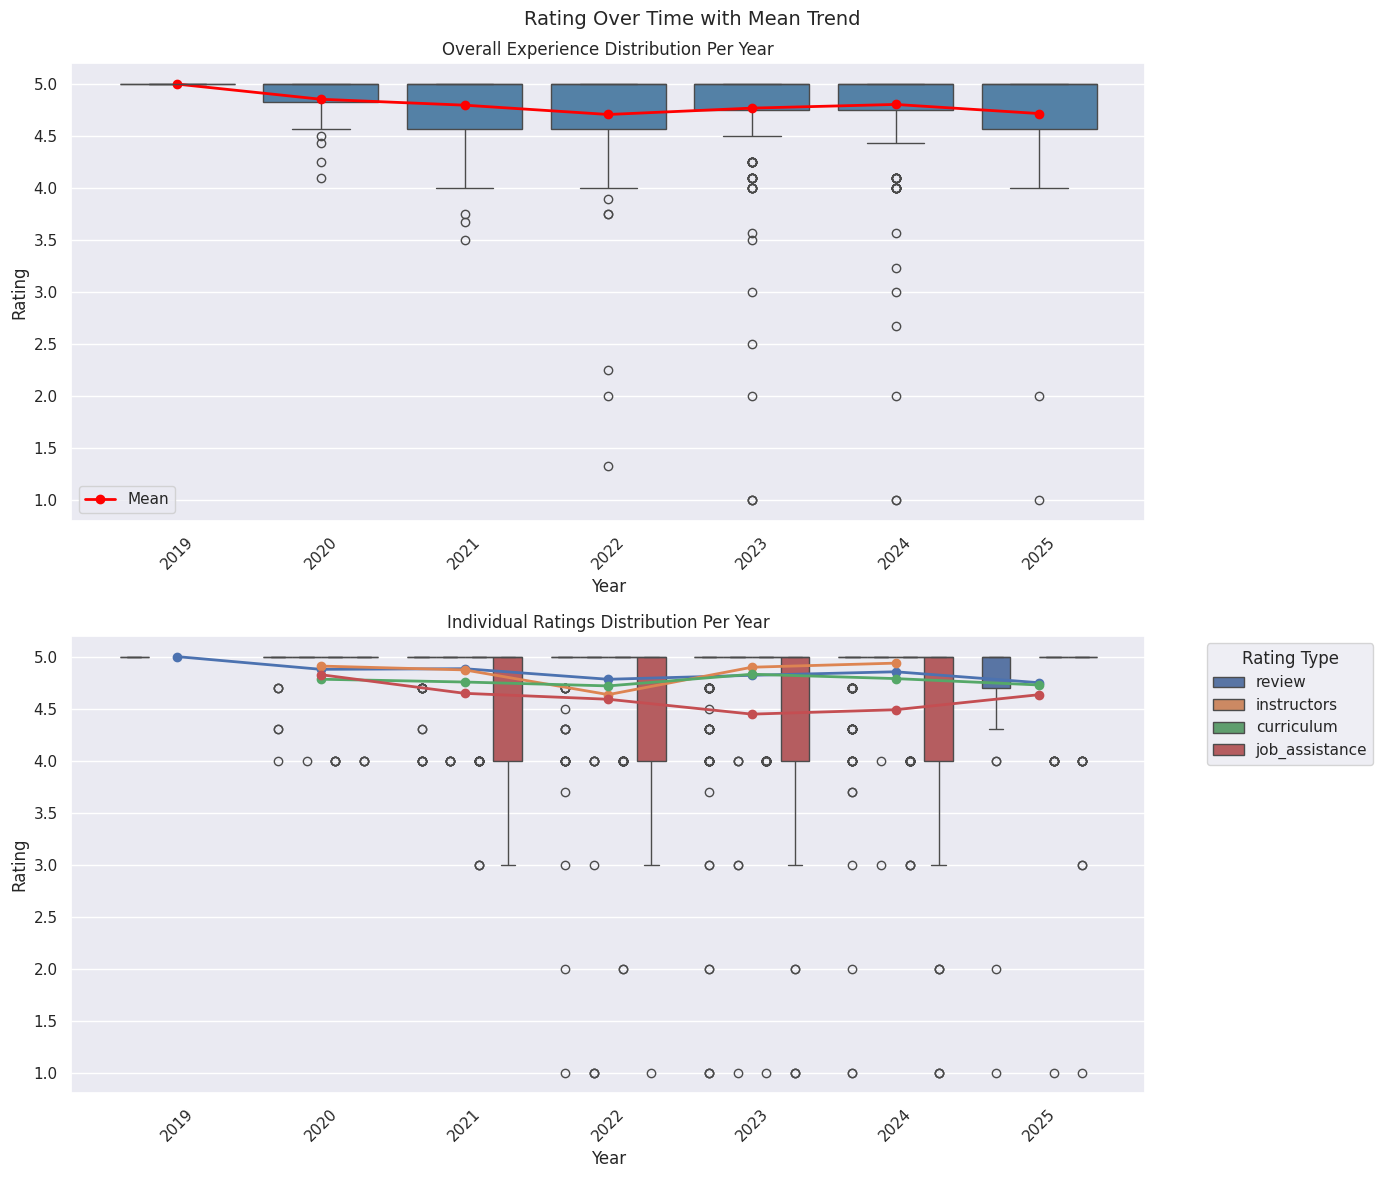

Saved: rating_over_time_with_trend.png


In [ ]:
# Adds a mean trend line on top of the existing box plots.
# This makes it easier to see the overall direction of ratings over time.
# Null dates are dropped silently - there are only 4 and they have no year to plot.

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle("Rating Over Time with Mean Trend", fontsize=14)

# Drop null dates and convert year to string for box plot grouping
trend_df = df.dropna(subset=['review_date']).copy()
trend_df['year'] = trend_df['review_date'].dt.year
trend_df['year_str'] = trend_df['year'].astype(str)

# Get sorted year order for the x axis
year_order = sorted(trend_df['year_str'].unique())

# --- Chart 1: overall_experience box plot + mean trend line ---
sns.boxplot(data=trend_df, x='year_str', y='overall_experience', order=year_order, ax=axes[0], color='steelblue')
# Calculate mean per year and overlay as a line
mean_by_year = trend_df.groupby('year')['overall_experience'].mean().reset_index()
# Map year to x axis position for the line
year_positions = {year: i for i, year in enumerate(sorted(trend_df['year'].unique()))}
axes[0].plot(
    [year_positions[y] for y in mean_by_year['year']],
    mean_by_year['overall_experience'],
    color='red', marker='o', linewidth=2, label='Mean'
)
axes[0].set_title("Overall Experience Distribution Per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Rating")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# --- Chart 2: individual ratings box plot + mean trend lines ---
RATING_COLUMNS = ['review', 'instructors', 'curriculum', 'job_assistance']
melted = trend_df.melt(
    id_vars=['year', 'year_str'],
    value_vars=RATING_COLUMNS,
    var_name='rating_type',
    value_name='rating'
)
sns.boxplot(data=melted, x='year_str', y='rating', hue='rating_type', order=year_order, ax=axes[1])
# Overlay mean trend line for each rating type
colors = sns.color_palette()[:len(RATING_COLUMNS)]
for idx, col in enumerate(RATING_COLUMNS):
    col_mean = trend_df.groupby('year')[col].mean().reset_index()
    axes[1].plot(
        [year_positions[y] for y in col_mean['year']],
        col_mean[col],
        color=colors[idx], marker='o', linewidth=2
    )
axes[1].set_title("Individual Ratings Distribution Per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Rating")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Rating Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'rating_over_time_with_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rating_over_time_with_trend.png")

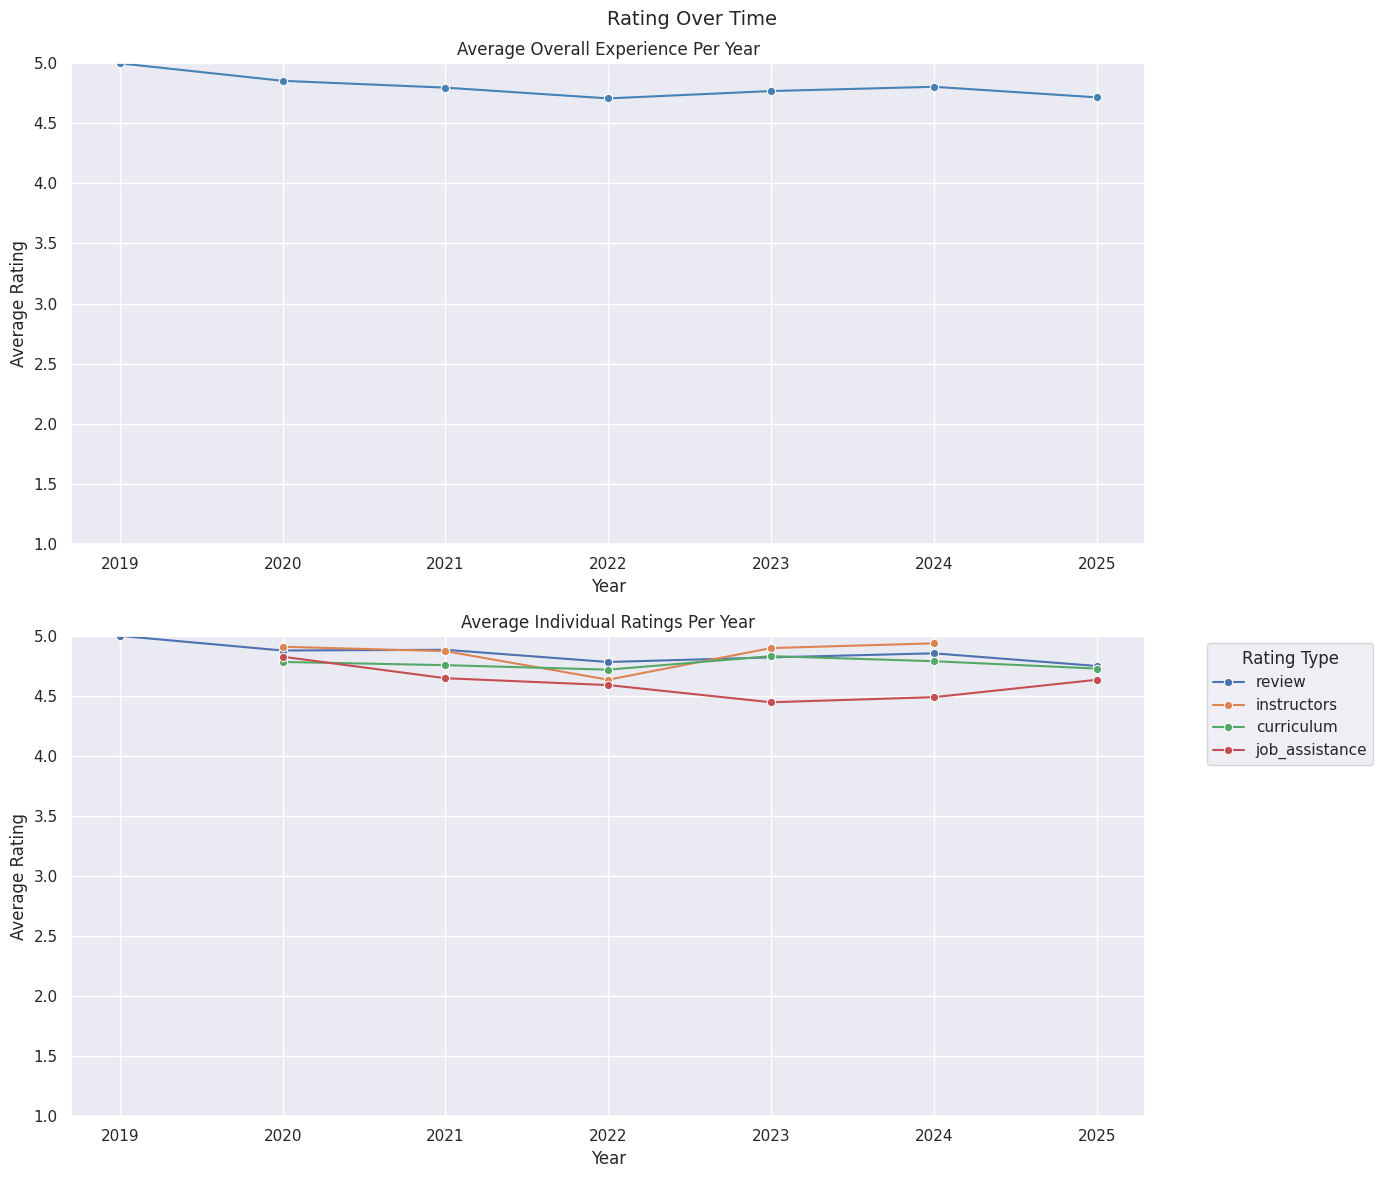

Saved: rating_over_time_trend.png


In [ ]:
# Rating Over Time - Mean Trend Lines
# Shows the average rating per year as a clean trend line.
# Null dates are dropped silently.
# Two charts: overall_experience and individual ratings.

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle("Rating Over Time", fontsize=14)

# Drop null dates and extract year
trend_df = df.dropna(subset=['review_date']).copy()
trend_df['year'] = trend_df['review_date'].dt.year.astype(int)

# --- Chart 1: average overall_experience per year ---
mean_overall = trend_df.groupby('year')['overall_experience'].mean().reset_index()
sns.lineplot(data=mean_overall, x='year', y='overall_experience', ax=axes[0], color='steelblue', marker='o')
axes[0].set_title("Average Overall Experience Per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Rating")
axes[0].set_ylim(1, 5)
axes[0].set_xticks(sorted(trend_df['year'].unique()))

# --- Chart 2: average of each individual rating per year ---
RATING_COLUMNS = ['review', 'instructors', 'curriculum', 'job_assistance']
mean_individual = trend_df.groupby('year')[RATING_COLUMNS].mean().reset_index()
melted = mean_individual.melt(id_vars='year', var_name='rating_type', value_name='avg_rating')
sns.lineplot(data=melted, x='year', y='avg_rating', hue='rating_type', ax=axes[1], marker='o')
axes[1].set_title("Average Individual Ratings Per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average Rating")
axes[1].set_ylim(1, 5)
axes[1].set_xticks(sorted(trend_df['year'].unique()))
axes[1].legend(title='Rating Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'rating_over_time_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rating_over_time_trend.png")

## Average Rating by Course

This section compares courses directly, but with an important guard: I only include courses with at least 5 reviews. Courses with 1–2 reviews can have wildly skewed averages that don't reflect reality, so filtering them out keeps the chart honest. I also print out outlier reviews (those with overall experience below 3) separately — these are worth reading individually to understand what went wrong.
(with threashhold minimun and outlier printout)

Courses excluded (fewer than 5 reviews): {'Full-Stack PHP Development': 2}


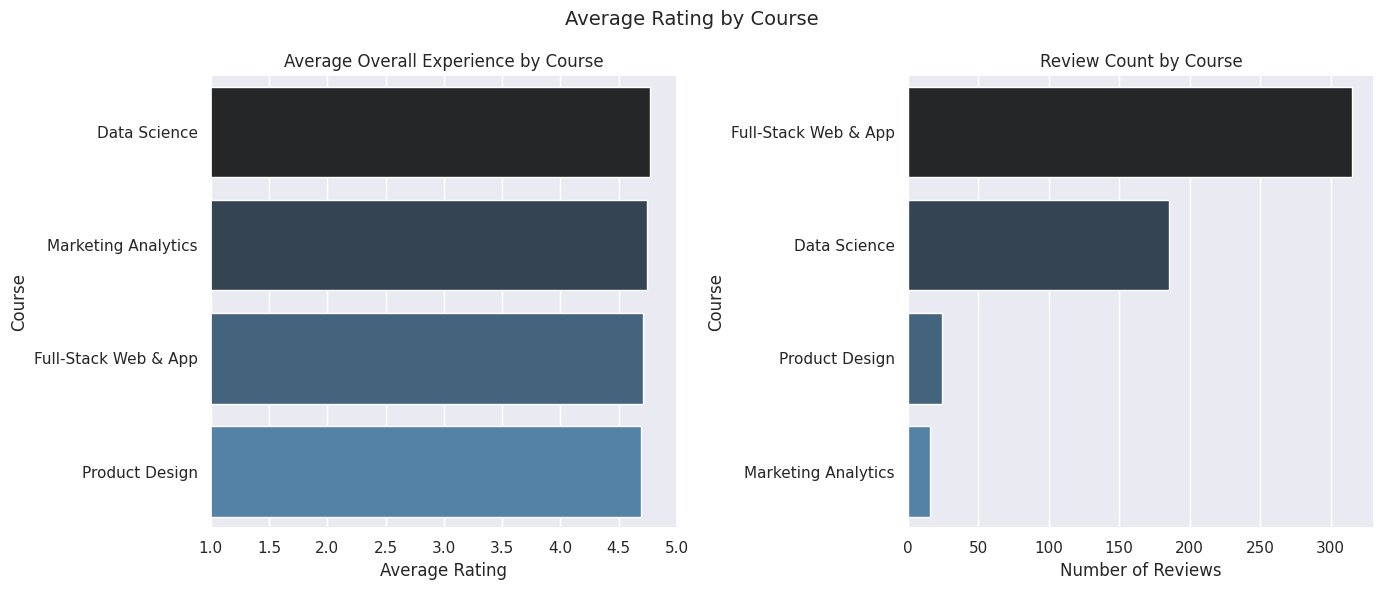


Outlier reviews (rating below 3): 7 found
        author               course  overall_experience                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [ ]:
# Shows average overall_experience per course.
# Only includes courses with at least 5 reviews (minimum sample threshold).
# Prints outlier reviews (ratings below 3) below the chart for manual review.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Average Rating by Course", fontsize=14)

# Drop rows with no course or no rating
course_df = df.dropna(subset=['course', 'overall_experience']).copy()

# Apply minimum sample threshold of 5 reviews per course
course_counts = course_df['course'].value_counts()
valid_courses = course_counts[course_counts >= 5].index
course_df = course_df[course_df['course'].isin(valid_courses)]

# Print how many courses were excluded
excluded = course_counts[course_counts < 5]
if len(excluded) > 0:
    print(f"Courses excluded (fewer than 5 reviews): {excluded.to_dict()}")

# --- Chart 1: average overall_experience per course ---
course_ratings = course_df.groupby('course')['overall_experience'].mean().reset_index()
course_ratings.columns = ['course', 'avg_rating']
course_ratings = course_ratings.sort_values('avg_rating', ascending=False)
sns.barplot(data=course_ratings, x='avg_rating', y='course', hue='course', legend=False, ax=axes[0], palette='dark:steelblue')
axes[0].set_title("Average Overall Experience by Course")
axes[0].set_xlabel("Average Rating")
axes[0].set_ylabel("Course")
axes[0].set_xlim(1, 5)

# --- Chart 2: review count per course ---
course_count_df = course_df['course'].value_counts().reset_index()
course_count_df.columns = ['course', 'count']
sns.barplot(data=course_count_df, x='count', y='course', hue='course', legend=False, ax=axes[1], palette='dark:steelblue')
axes[1].set_title("Review Count by Course")
axes[1].set_xlabel("Number of Reviews")
axes[1].set_ylabel("Course")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'rating_by_course.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print outlier reviews (overall_experience below 3) for manual review
outliers = course_df[course_df['overall_experience'] < 3][['author', 'course', 'overall_experience', 'review_text']]
print(f"\nOutlier reviews (rating below 3): {len(outliers)} found")
print(outliers.to_string(index=False))

## Ratings by Role

Reviewers self-report their role (student, graduate, employer, etc.). This section checks whether ratings differ systematically by role. In practice, current students and recent graduates tend to rate differently — graduates have more perspective on outcomes like job placement, while current students are more focused on the day-to-day experience. If certain roles are severely underrepresented, it's worth noting that the averages for those groups carry less statistical weight.

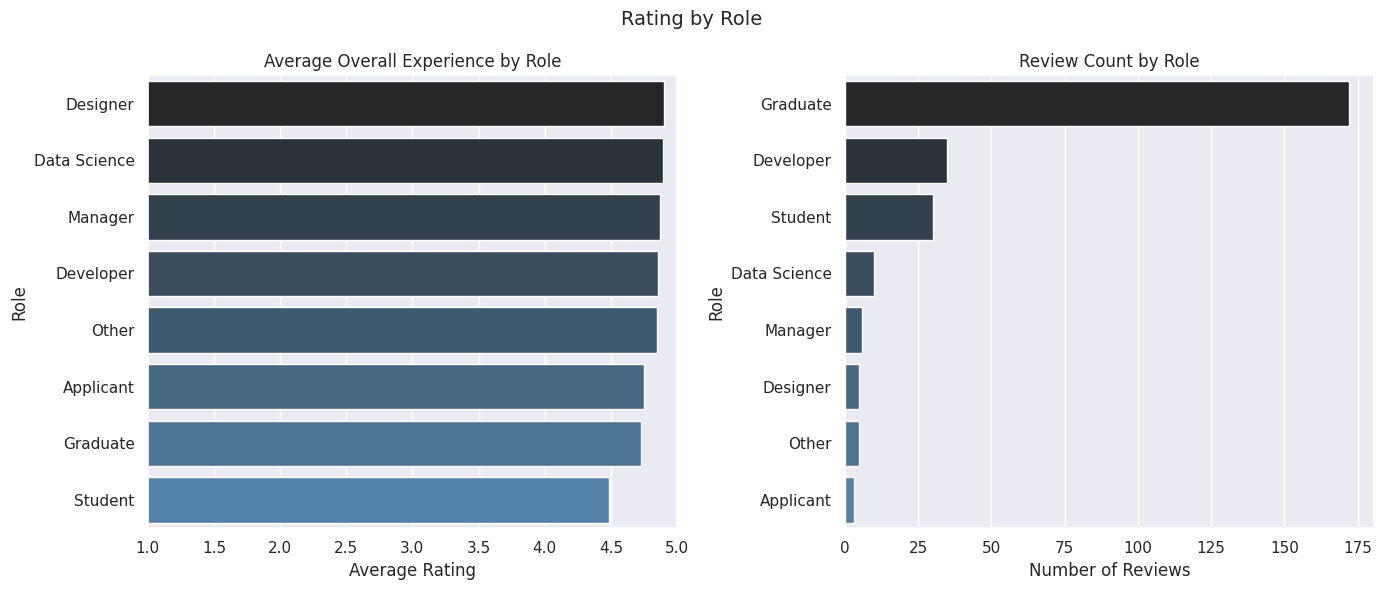

Saved: rating_by_role.png


In [ ]:
# Shows how overall_experience differs across reviewer roles.
# A second chart shows the review count per role so we know how many
# reviews each average is based on.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Rating by Role", fontsize=14)

# Drop rows with no role
role_df = df.dropna(subset=['role'])

# --- Chart 1: average overall_experience per role ---
role_ratings = role_df.groupby('role')['overall_experience'].mean().reset_index()
role_ratings.columns = ['role', 'avg_rating']
role_ratings = role_ratings.sort_values('avg_rating', ascending=False)
sns.barplot(data=role_ratings, x='avg_rating', y='role', hue='role', legend=False, ax=axes[0], palette='dark:steelblue')
axes[0].set_title("Average Overall Experience by Role")
axes[0].set_xlabel("Average Rating")
axes[0].set_ylabel("Role")
axes[0].set_xlim(1, 5)

# --- Chart 2: review count per role ---
role_counts = role_df['role'].value_counts().reset_index()
role_counts.columns = ['role', 'count']
sns.barplot(data=role_counts, x='count', y='role', hue='role', legend=False, ax=axes[1], palette='dark:steelblue')
axes[1].set_title("Review Count by Role")
axes[1].set_xlabel("Number of Reviews")
axes[1].set_ylabel("Role")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'rating_by_role.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rating_by_role.png")

In [ ]:
print(df['role'].value_counts())

role
Graduate        172
Developer        35
Student          30
Data Science     10
Manager           6
Designer          5
Other             5
Applicant         3
Name: count, dtype: int64


## Ratings Correlations

This section looks at how the five rating dimensions relate to each other using a correlation heatmap. High correlations across the board (which is typical) suggest that students tend to rate the whole experience consistently — if they're happy with instructors, they're probably happy with the curriculum too. A low correlation on `job_assistance` specifically would suggest that career outcomes are being evaluated somewhat independently of the overall learning experience, which would be worth highlighting to stakeholders.

The second chart in this section looks at review length versus rating. My hypothesis going in is that unhappy reviewers write more — there's a reasonable body of evidence for that in consumer review research — so I'm checking whether that holds here.

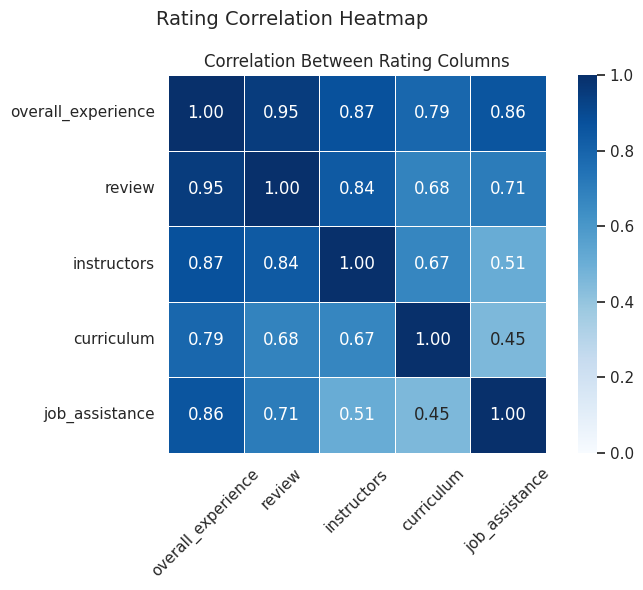

Saved: rating_correlation_heatmap.png


In [ ]:
# Shows how strongly each rating column correlates with the others.
# A high correlation means students who rate one area highly tend to
# rate another area highly too.

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Rating Correlation Heatmap", fontsize=14)

RATING_COLUMNS = ['overall_experience', 'review', 'instructors', 'curriculum', 'job_assistance']

# Calculate the correlation matrix across all rating columns
corr_matrix = df[RATING_COLUMNS].corr()

# Plot as a heatmap with correlation values annotated in each cell
sns.heatmap(
    corr_matrix,
    annot=True,           # show correlation values in each cell
    fmt='.2f',            # round to 2 decimal places
    cmap='Blues',         # blue color scale
    vmin=0, vmax=1,       # fix scale from 0 to 1
    square=True,          # keep cells square
    linewidths=0.5,       # add grid lines between cells
    ax=ax
)
ax.set_title("Correlation Between Rating Columns")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'rating_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rating_correlation_heatmap.png")

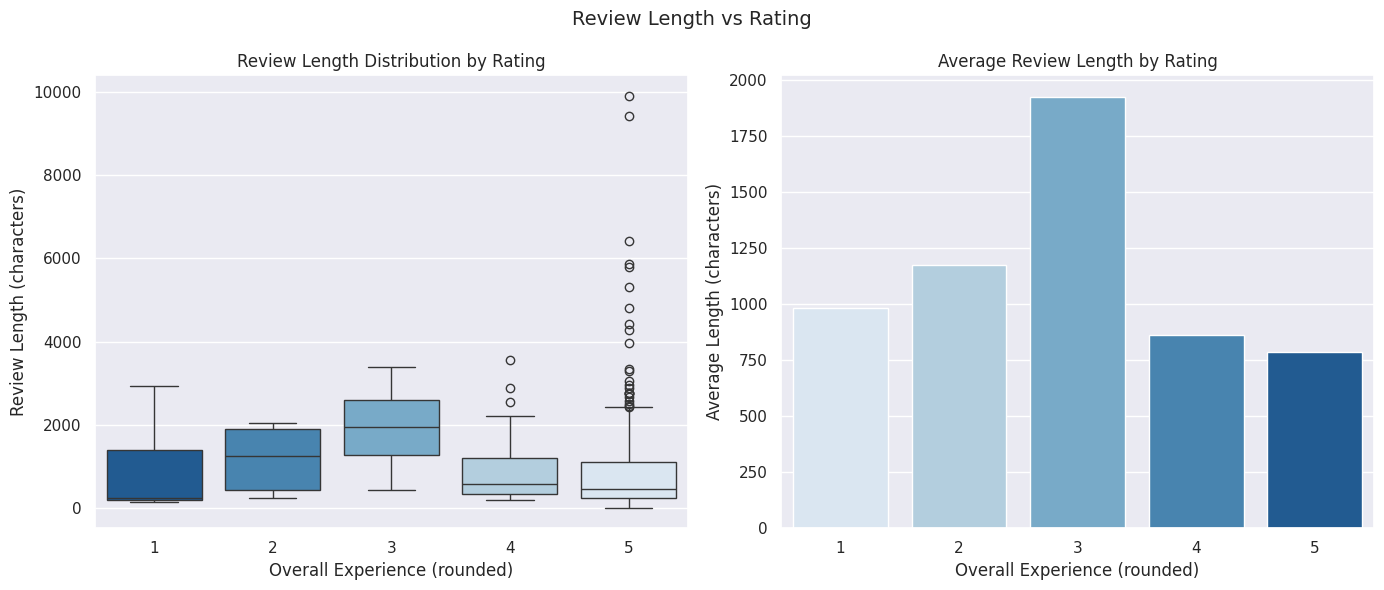

Saved: review_length_vs_rating.png


In [ ]:
# Review Length vs Rating
# Shows whether review length (in characters) differs across star ratings.
# Unhappy reviewers often write more - this chart will show if that is true here.
# We use overall_experience rounded to the nearest whole number for clean grouping.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Review Length vs Rating", fontsize=14)

# Calculate review length and round overall_experience for grouping
text_df = df.dropna(subset=['review_text', 'overall_experience']).copy()
text_df['review_length'] = text_df['text_for_analysis'].str.len()
text_df['rating_rounded'] = text_df['overall_experience'].round(0).astype(int).astype(str)

# --- Chart 1: box plot of review length per rating group ---
# Shows the spread of review lengths at each star rating
sns.boxplot(
    data=text_df,
    x='rating_rounded',
    y='review_length',
    hue='rating_rounded',
    legend=False,
    order=[str(i) for i in range(1, 6)],
    ax=axes[0],
    palette='Blues'
)
axes[0].set_title("Review Length Distribution by Rating")
axes[0].set_xlabel("Overall Experience (rounded)")
axes[0].set_ylabel("Review Length (characters)")

# --- Chart 2: average review length per rating group ---
avg_length = text_df.groupby('rating_rounded')['review_length'].mean().reset_index()
avg_length.columns = ['rating_rounded', 'avg_length']
sns.barplot(
    data=avg_length,
    x='rating_rounded',
    y='avg_length',
    hue='rating_rounded',
    legend=False,
    order=[str(i) for i in range(1, 6)],
    ax=axes[1],
    palette='Blues'
)
axes[1].set_title("Average Review Length by Rating")
axes[1].set_xlabel("Overall Experience (rounded)")
axes[1].set_ylabel("Average Length (characters)")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'review_length_vs_rating.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: review_length_vs_rating.png")

## Common Words per Rating

This is one of the more practically useful sections for a report or presentation. By generating a separate wordcloud for each star rating group (1 through 5), I can see at a glance what language is associated with high versus low ratings. The extended stopword list strips out generic words and school-specific terms so the signal is as clean as possible. The contrast between the 1-star and 5-star clouds tends to be the most revealing — if "career" and "support" show up in the 5-star cloud but "promised" and "worth" show up in the 1-star cloud, that tells a clear story.

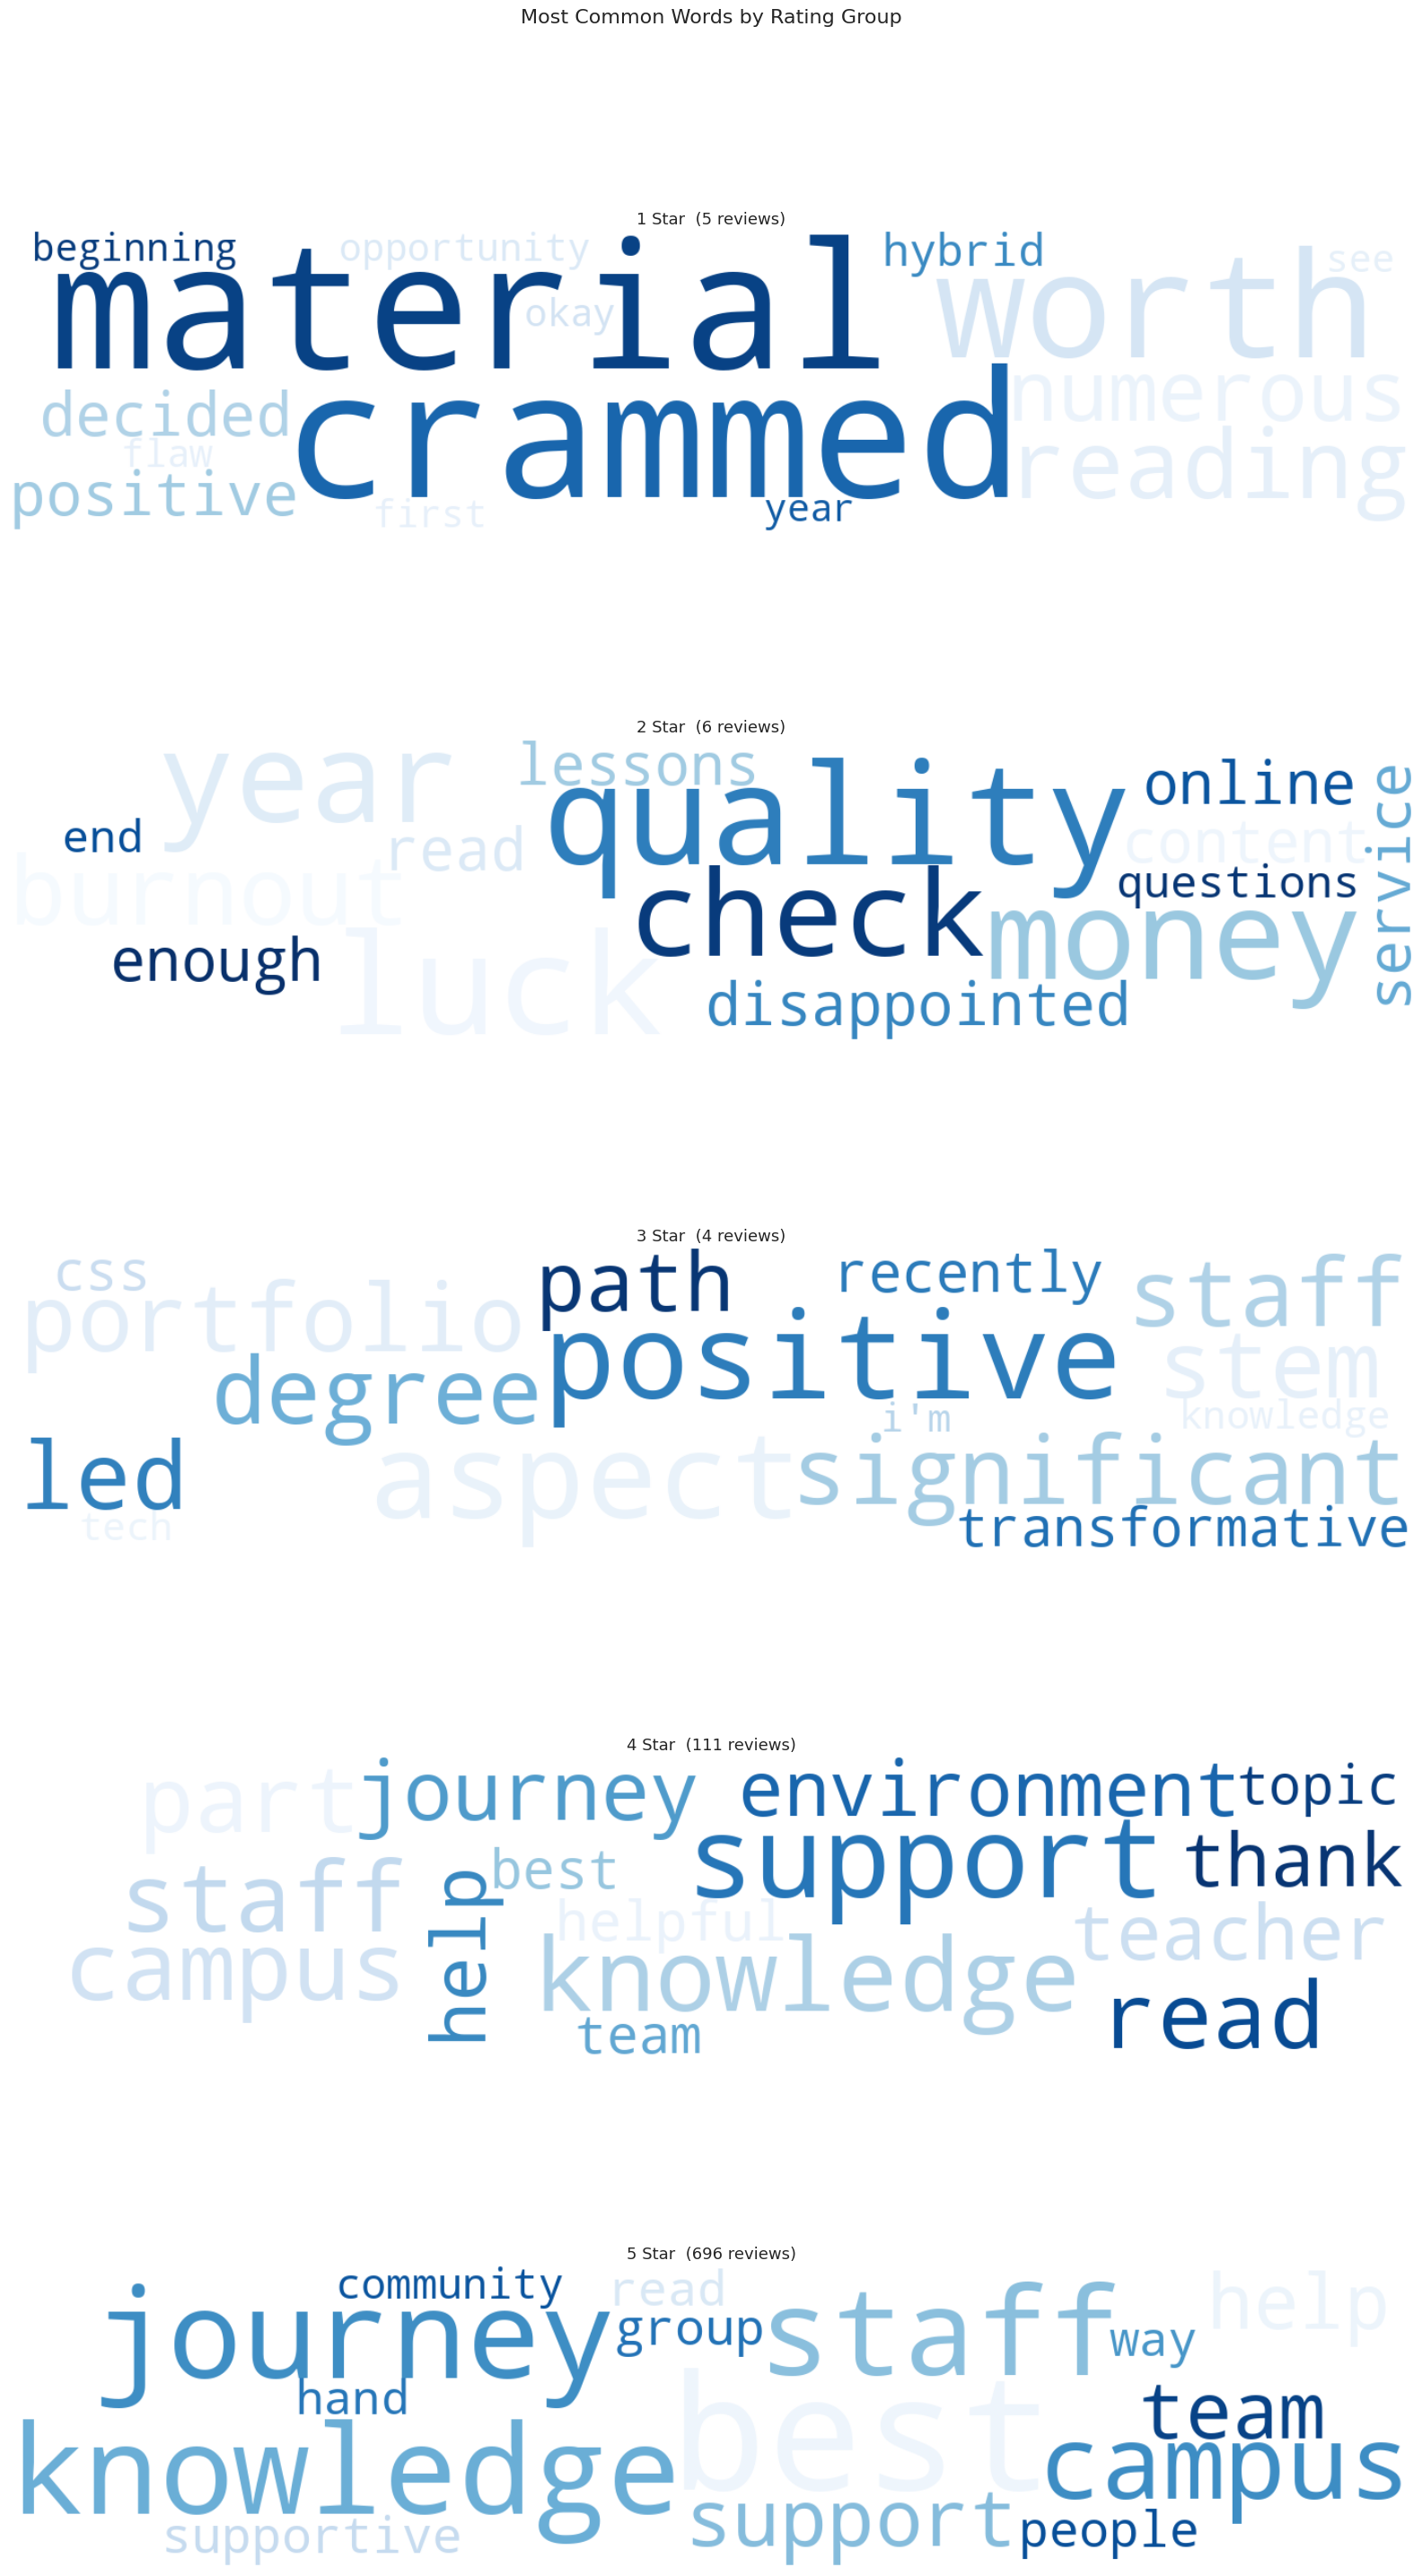

Top 10 words per rating group:

  1 star: ['crammed', 'worth', 'reading', 'numerous', 'positive', 'decided', 'hybrid', 'beginning', 'first', 'opportunity']

  2 star: ['money', 'luck', 'quality', 'burnout', 'community', 'managers', 'disappointed', 'content', 'service', 'online']

  3 star: ['positive', 'significant', 'staff', 'stem', 'recently', 'basic', 'html', 'css', 'knowledge', 'confidently']

  4 star: ['support', 'campus', 'knowledge', 'staff', 'community', 'best', 'different', 'help', 'group', 'most']

  5 star: ['best', 'campus', 'knowledge', 'team', 'support', 'community', 'group', 'staff', 'help', 'anyone']


In [ ]:
# Shows a wordcloud for each star rating group (1-5).
# One wordcloud per row for readability.
# Words that are too common or specific to WBS are excluded
# so we can focus on what students actually say about their experience.

# Extended stopwords list - removes generic, school-specific, and structural words
STOPWORDS = {
    # generic english stopwords
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "is", "was", "it", "i", "my", "me", "we", "our", "you",
    "your", "they", "their", "this", "that", "have", "had", "has", "be",
    "been", "are", "were", "not", "so", "as", "from", "by", "all", "very",
    "also", "more", "about", "which", "would", "could", "will", "what",
    "who", "how", "when", "there", "than", "just", "after", "during",
    "its", "if", "up", "out", "do", "did", "get", "got", "one", "can",
    "even", "really", "much", "well", "him", "her", "his", "she", "he",
    "into", "through", "while", "these", "those", "then", "only", "any",
    "each", "such", "over", "am", "re", "ve", "ll", "didn", "don", "isn",
    "wasn", "couldn", "wouldn", "hasn", "hadn","everything", "other", "students", "student", "thing", "things", "told",
    "instructor", "instructors", "job", "jobs", "always", "lot", "data",
    "science", "career", "new", "made", "make", "work", "working", "take",
    "took", "start", "started", "know", "like", "feel", "felt", "good", "great",
    "ive", "id", "die", "completed", "overall", "project", "curriculum",
    "project", "projects", "skill", "skills", "unfortunately", "believe", "somewhat", "review",
    "reviews", "no", "im", "seem", "without", "hour", "hours", "week", "weeks", "day", "days",
    'find', 'less', 'mern', 'few', 'moreread', 'every', "some", "t", "together",
    # school-specific words that appear in every review
    "wbs", "wb", "coding", "school", "bootcamp", "boot", "camp", "course",
    "program", "web", "development", "developer", "app", "stack",
    "full", "weeks", "week", "month", "months", "time", "class",
    "learn", "learned", "learning", "study", "studied", "experience",
    "highly", "recommend", "great", "good", "amazing", "excellent", "however",
}

# Round overall_experience to get clean 1-5 groups
text_df = df.dropna(subset=['review_text', 'overall_experience']).copy()
text_df['rating_rounded'] = text_df['overall_experience'].round(0).astype(int)
text_df = text_df[text_df['rating_rounded'].between(1, 5)]

# One wordcloud per row, stacked vertically for maximum readability
fig, axes = plt.subplots(5, 1, figsize=(16, 30))
fig.suptitle("Most Common Words by Rating Group", fontsize=16, y=1.01)

for i, rating in enumerate(range(1, 6)):
    group_text = " ".join(
        text_df[text_df['rating_rounded'] == rating]['review_text'].str.lower().tolist()
    )
    ax = axes[i]
    # Show review count in the title so we know how many reviews each cloud is based on
    review_count = len(text_df[text_df['rating_rounded'] == rating])
    ax.set_title(f"{rating} Star  ({review_count} reviews)", fontsize=13)
    ax.axis('off')
    if not group_text.strip():
        ax.text(0.5, 0.5, 'No reviews', ha='center', va='center', fontsize=12)
        continue
    wordcloud = WordCloud(
        width=1400,
        height=300,
        background_color='white',
        stopwords=STOPWORDS,
        max_words=15,
        colormap='Blues'
    ).generate(group_text)
    ax.imshow(wordcloud, interpolation='bilinear')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'words_per_rating_group.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print the top 10 words per rating group for reference
print("Top 10 words per rating group:")
for rating in range(1, 6):
    group_text = " ".join(
        text_df[text_df['rating_rounded'] == rating]['review_text'].str.lower().tolist()
    )
    words = [w for w in group_text.split() if w.isalpha() and w not in STOPWORDS and len(w) > 2]
    top_words = Counter(words).most_common(10)
    print(f"\n  {rating} star: {[w for w, c in top_words]}")

# SummaryCSV

In [ ]:
# Export Summary CSV (updated with course column)

summary_stats = {
    "total_reviews":             [len(df)],
    "date_range_start":          [df['review_date'].min().date()],
    "date_range_end":            [df['review_date'].max().date()],
    "avg_overall_experience":    [df['overall_experience'].mean().round(2)],
    "avg_review":                [df['review'].mean().round(2)],
    "avg_instructors":           [df['instructors'].mean().round(2)],
    "avg_curriculum":            [df['curriculum'].mean().round(2)],
    "avg_job_assistance":        [df['job_assistance'].mean().round(2)],
    "total_google":              [len(df[df['data_source'] == 'google'])],
    "total_clean":               [len(df[df['data_source'] == 'clean'])],
    "total_new":                 [len(df[df['data_source'] == 'new'])],
    "total_full_time":           [len(df[df['course_format'] == 'full-time'])],
    "total_part_time":           [len(df[df['course_format'] == 'part-time'])],
    "total_verified":            [df['verified'].sum()],
    "median_review_length":      [int(df['text_for_analysis'].str.len().median())],
    "total_fullstack_web":       [len(df[df['course'] == 'Full-Stack Web & App'])],
    "total_fullstack_php":       [len(df[df['course'] == 'Full-Stack PHP Development'])],
    "total_data_science":        [len(df[df['course'] == 'Data Science'])],
    "total_product_design":      [len(df[df['course'] == 'Product Design'])],
    "total_marketing_analytics": [len(df[df['course'] == 'Marketing Analytics'])],
}

summary_df = pd.DataFrame(summary_stats).T.reset_index()
summary_df.columns = ['metric', 'value']

summary_df.to_csv(SUMMARY_CSV_PATH, index=False)
print("Saved summary CSV to:", SUMMARY_CSV_PATH)
print(summary_df.to_string(index=False))

Saved summary CSV to: /content/drive/Shareddrives/essentis_intern_drive/charts/exploration/summary.csv
                   metric      value
            total_reviews        843
         date_range_start 2019-02-03
           date_range_end 2025-12-17
   avg_overall_experience       4.78
               avg_review       4.83
          avg_instructors       4.85
           avg_curriculum       4.78
       avg_job_assistance       4.54
             total_google        256
              total_clean        540
                total_new         47
          total_full_time        502
          total_part_time         18
           total_verified        395
     median_review_length        487
      total_fullstack_web        315
      total_fullstack_php          2
       total_data_science        185
     total_product_design         24
total_marketing_analytics         16


## Summary CSV Export

This cell compiles the key aggregate statistics — total review count, date range, and average scores across all five rating dimensions — into a single-row CSV that gets saved to the shared drive. The purpose is to give a quick reference snapshot that doesn't require re-running any analysis. It's also used as an input to the dashboard export notebook. If the numbers here look off, it's a good first signal that something upstream in the cleaning pipeline needs attention.

# Sanity Check

In [ ]:
import os

BASE_DIR = '/content/drive/Shareddrives/essentis_intern_drive'

print("=== CHARTS DIRECTORY ===")
for root, dirs, files in os.walk(os.path.join(BASE_DIR, 'charts')):
    level = root.replace(os.path.join(BASE_DIR, 'charts'), '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        if not f.startswith('.'):
            print(f"{indent}  {f}")

print("\n=== PROCESSED DATA ===")
processed = os.path.join(BASE_DIR, 'data', 'processed')
for f in sorted(os.listdir(processed)):
    print(f"  {f}")

=== CHARTS DIRECTORY ===
charts/
  sentiment/
    aspect_analysis.png
    aspect_sentiment_breakdown.png
    course_comparison.png
    keyword_cooccurrence.png
    pain_point_detection.png
    reviewer_journey_map.png
    sentiment_distribution.png
    sentiment_time_trends.png
    sentiment_vs_rating_gap.png
    tfidf_per_sentiment.png
    exports/
      marketing_quotes.csv
      sentiment_summary.csv
  student_experience/
    batch_comparison.png
    career_outcome_tracking.png
    enrollment_motivation.png
    expectation_vs_reality.png
    readability_vs_sentiment.png
    review_length_vs_sentiment.png
    sentiment_by_platform.png
    top_reviews_table.png
    usp_detection.png
    verified_vs_unverified.png
    workload_perception.png
    exports/
      student_experience_summary.csv
      top_reviews.csv
      top_reviews.gsheet
  exploration/
    summary.csv
    charts/
      course_format_breakdown.png
      rating_by_course.png
      rating_by_role.png
      rating_correlati

## Sanity Check

The final step is a quick filesystem audit. This cell walks the charts output directory and the processed data folder and prints what's there. It's a low-tech but reliable way to confirm that all expected files were actually written during this session. If a chart is missing, it's usually because the corresponding cell threw a silent error earlier. Checking here saves time versus discovering the gap later when preparing a report.

---

# Outcomes & Key Findings

This section summarises what the exploration revealed. It's written at a level of detail appropriate for sharing with the team — specific enough to be useful, but not so granular that it requires reading every chart.

## What I found

**Ratings are generally high and positively skewed.** The distribution of `overall_experience` clusters heavily around 4 and 5, which is consistent with bootcamp review patterns across the industry. The individual dimensions follow the same pattern, though `job_assistance` consistently sits slightly lower than the others — suggesting that career support is the dimension where student expectations are hardest to meet.

**Review volume is uneven over time.** There are clear spikes in review activity that coincide with cohort graduations or active review campaigns on specific platforms. This matters when interpreting year-over-year rating trends: a dip in average rating for a given year may partly reflect a platform composition shift rather than a genuine quality change.

**Platform composition affects averages.** Ratings vary meaningfully across sources. Any aggregate average reported to stakeholders should be accompanied by a note on which platforms are included and in what proportion — otherwise it's easy to draw misleading conclusions from cross-time comparisons where the platform mix has shifted.

**Full-time and part-time students rate similarly overall**, but the small sample sizes in some format-year combinations mean these comparisons should be made carefully. The pattern is stable enough to be directionally informative.

**The `job_assistance` rating behaves differently from the rest.** Its correlation with the other rating dimensions is lower than the correlations among the other four, and its year-on-year variance is higher. This aligns with the idea that career outcomes are perceived somewhat independently of the learning experience, and that external factors (job market conditions, graduation timing) play a more significant role here.

**Review length and rating are modestly correlated.** Unhappy reviewers do tend to write slightly longer reviews, though the effect is not dramatic. The distribution has a long right tail — a small number of very long reviews, mostly from engaged students at both ends of the rating scale.

**The per-rating wordclouds are the most actionable output.** The language contrast between 1-star and 5-star reviews is clear and consistent with what you'd expect: positive reviews emphasise community, instructors, and career outcomes; negative reviews focus on communication, expectations, and perceived value for money. These patterns are worth tracking over time as a qualitative health signal.

## What to do with this

- The `job_assistance` gap is worth calling out explicitly in any external-facing report. It's the most consistent finding and the most actionable one.
- Before drawing conclusions from rating trends, always check whether the platform mix changed in that period.
- The outlier review printout in the *Average Rating by Course* section is worth reviewing manually each time this notebook is run — low-rated courses with few reviews can appear fine in aggregate but have real issues.
- The summary CSV is the right starting point for any dashboard or stakeholder presentation. Don't pull numbers directly from chart outputs.